# Plant Height Geospatial Tutorial

Welcome to the plant height geospatial tutorial! 

This tutorial is an example workflow for analyzing height for regions in a geojson shapefile using regional percentiles. The example data used in this tutorial comes from NDSU [BisonFly](https://github.com/filipematias23/Bison-Fly). You will need this data from this project to complete this tutorial, the zip file from BisonFly containing the relevant RGBs and DSMs is available for download [here.](https://drive.google.com/file/d/1_Uj3oaiSv31WpbGyyUCfKiKhAqQ_jPUN/view) Once you have downloaded the zip file, update the object named *user* and run the code below to add the folder to your local notebook.

**Note: Since this tutorial uses napari pop-up browser, this tutorial will only work using a local notebook.**

*Adapted for `plantcv-geospatial` by Eliza Seigel*

Updated April 2026

### Import libraries
Once you have downloaded the zip file containing the BisonFly example data, unzip the data folder in the next step. 

Otherwise, you can skip to the `read.geotif` step and provide the path to your data.

In [8]:
# Set the notebook display method.
%matplotlib widget
# If widget is not working, then change to inline

In [9]:
#Import libraries
import plantcv.plantcv as pcv
import plantcv.geospatial as gcv

In [10]:
# Set global params
# Plot debug images to the notebook
pcv.params.debug = "plot"

### 2. Read in the DSM file as a grayscale image

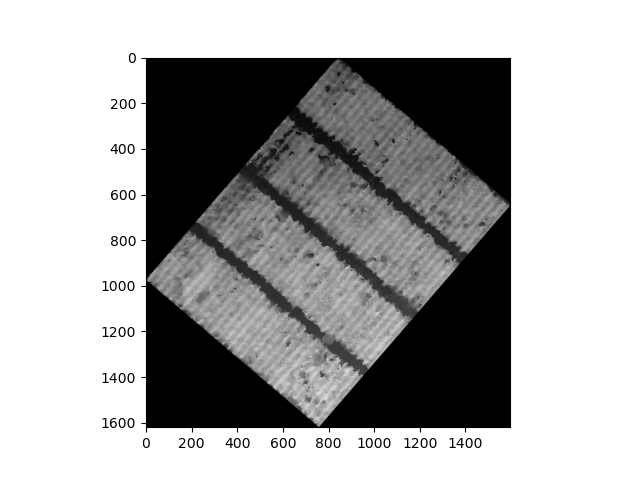

In [11]:
# Next we are going to read in the DSM that will be used in our function.
img = gcv.read.geotif(filename="./img/test_crop_from_QGIS.tif",
                            bands="gray"
                           )

### 5. Create a shapefile interactively with Napari
This function opens a Napari window, where you can create layers. Please see the images and instructions below before you run this code.


In [12]:
# This cell opens a Napari window, where you can create layers.
# Run this cell, then draw the field boundary in the field_boundary layer in Napari.
# For this field, we will zoom in on only one of the 10 x 20 blocks
# There are 4 blocks starting on the left side, choose one to draw a shape around
# Leave some space on the outer edge of your field, approximately half the space between each plot
# In Napari, select field_boundary, choose the polygon tool, and draw the field outline, then press enter.
# *Note* keep the napari viewer open!

editor = gcv.create_shapes.InteractiveShapes(
    img=img,
    viewer_type="napari",
    field_layer="field_boundary",
    show=True
    )

#### Create corner points around your field
With the points layer highlighted, click on the Add points tool (see example image). 

**Starting in the top left corner**, make 4 points in each corner of your field going clockwise. 

Don't worry about perfectly aligning the points of the rectangle, the 4 points just have to contain the whole field. 

![](https://raw.githubusercontent.com/danforthcenter/plantcv-geospatial-tutorial-plant-height/main/img/tutorial-imgs/img2.png)

#### Save the points as a geojson
Without closing the Napari window, change the `dest` to the location you want to save the geojson file. 
After saving the points, you can close the Napari window.

In [ ]:
gcv.convert.points(img=img, source=viewer, dest="./points.geojson")

### 6. Create a flexible grid layout and save it as a geojson
In a new Napari window, add points to the Points layer indicating where the top left corner of your plots are (see example image).


In [ ]:
img=img
viewer = napari.Viewer()
viewer.add_image(img)
viewer.add_points(size = 20)

**There are two options to mark plots with a grid.**
* Manually click the **top left corner** of each plot
* Use the auto-grid functionality by adding **one** point at the top left of each row and increasing `num_rows` in the code below.

Note that the example image shows the first option where every plot is clicked.

![](https://raw.githubusercontent.com/danforthcenter/plantcv-geospatial-tutorial-plant-height/main/img/tutorial-imgs/img3.png)

Without closing the Napari window, run the next cell of code to save the points you clicked to a geojson file. 

In [ ]:
# This code saves the 'gridpoints' layer as a geojson.
gcv.convert.points(img=img, source = viewer, dest="./grid_points.geojson")

Using the two geojson files you created above, create a grid marking the plot boundaries.

In [ ]:
# The gridcells function creates grids from the designated plot points. Adjust the dimensions of the range length and row length as needed.
gridcells = gcv.create_shapes.grid_from_coords(img = geoimg, 
                                               field_corners_path = "./points.geojson", 
                                               plot_geojson_path = "./grid_points.geojson", 
                                               out_path = "./gridcells.geojson", 
                                               num_rows=1,
                                               range_length = 2.5, 
                                               row_length = 1.5)

### 8. Measure height

In [ ]:
# Analyze height for each region in the geojson.
bounds = gcv.analyze.height_percentile(dsm=dsm,
                           geojson="./gridcells.geojson",
                           lower=25,
                           upper=90,
                           label="default")



### 9. Access output data and save out to file 

In [ ]:
# To access individual observation values:
print(pcv.outputs.observations["default_1"]["plant_height"]["value"])
print(pcv.outputs.observations["default_1"]["plant_height"]["scale"])


In [ ]:
#To save the outputs as a shapefile: 
pcv.outputs.save_results(filename="./height_results.json")    
